# EDA — UAVDT
Detección de objetos desde perspectiva aérea  
Miguel Alejandro Flores Sotelo · Sergio de Jesús Castillo Molano

## Objetivo
Caracterizar el dataset UAVDT antes de usarlo como conjunto de
**validación cruzada**. El EDA de UAVDT es reducido porque no es
el dataset de entrenamiento. El foco es compararlo contra VisDrone
para entender el **domain shift** entre ambos dominios aéreos.

## Contenido
1. Parseo de anotaciones → DataFrame
2. Distribución de clases
3. Comparativa directa VisDrone vs UAVDT

> **Nota:** A diferencia del EDA de VisDrone, no se realiza análisis
> de tamaños de bounding boxes (small/medium/large criterio COCO).
> Las anotaciones de UAVDT ya vienen en **formato YOLO normalizado**
> (valores entre 0 y 1), por lo que no es posible comparar directamente
> con los umbrales COCO en píxeles sin conocer la resolución exacta
> de cada imagen. Este análisis no es necesario dado que UAVDT es
> únicamente dataset de validación cruzada, no de entrenamiento.

## 1. Parseo de anotaciones → DataFrame

Las anotaciones de UAVDT de Zenodo ya vienen en **formato YOLO normalizado**:
- Valores entre 0 y 1 (normalizados al tamaño de la imagen)
- 3 clases: 0=car, 1=truck, 2=bus

In [1]:
#Imports
import yaml
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

#Cargar configuración
PROJECT_ROOT=Path("..")
config_path =PROJECT_ROOT / "configs" / "uavdt.yaml"

with open(config_path) as f:
    cfg=yaml.safe_load(f)

DATASET_ROOT=PROJECT_ROOT/cfg["path"]
LABELS_TRAIN=DATASET_ROOT/cfg["labels"]["train"]
CLASS_NAMES=cfg["names"]

# Carpetas de salida
output_dir = PROJECT_ROOT/"results"/"figures"/"eda_uavdt"
tables_dir = PROJECT_ROOT/"results"/"tables"/"eda_uavdt"
output_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

print(f"Raíz del dataset:{DATASET_ROOT.resolve()}")
print(f"Labels train:{LABELS_TRAIN.resolve()}")
print(f"Clases:{CLASS_NAMES}")

Raíz del dataset:/home/magicmike/TT-deteccion-aerea/data/uavdt
Labels train:/home/magicmike/TT-deteccion-aerea/data/uavdt/labels/train
Clases:{0: 'car', 1: 'truck', 2: 'bus'}


In [3]:
# Parsear anotaciones del split train
records=[]
label_files=sorted(LABELS_TRAIN.glob("*.txt"))

for txt_file in label_files:
    img_name=txt_file.stem
    with open(txt_file) as f:
        for line in f:
            parts=line.strip().split()
            if len(parts)!=5:
                continue
            cat_id, x_c, y_c, w, h=parts
            cat_id=int(cat_id)
            w, h=float(w), float(h)

            records.append({
                "image":img_name,
                "cat_id":cat_id, #category_id (0,1,2)
                "class":CLASS_NAMES[cat_id],
                "x_center":float(x_c),
                "y_center":float(y_c),
                "w_norm":w,
                "h_norm":h,
                "area_norm":round(w * h, 6),
                "aspect_ratio":round(w / h, 3) if h > 0 else 0,
            })

df_u=pd.DataFrame(records)

print(f"Total de detecciones válidas (train):{len(df_u):,}")
print(f"Imágenes únicas:{df_u['image'].nunique():,}")
print(f"Clases presentes:{df_u['class'].nunique()}")
print()
df_u.head(10)

Total de detecciones válidas (train):35,007
Imágenes únicas:1,266
Clases presentes:3



,image,cat_id,class,x_center,y_center,w_norm,h_norm,area_norm,aspect_ratio
0,DJI-405-720p00201,0,car,0.633203,0.335417,0.024219,0.029167,0.000706,0.830
1,DJI-405-720p00201,0,car,0.481641,0.344444,0.025781,0.025000,0.000645,1.031
2,DJI-405-720p00201,2,bus,0.810937,0.629167,0.034375,0.030556,0.001050,1.125
3,DJI-405-720p00201,0,car,0.839844,0.399306,0.028125,0.023611,0.000664,1.191
4,DJI-405-720p00201,0,car,0.108203,0.318056,0.025781,0.030556,0.000788,0.844
5,DJI-405-720p00201,0,car,0.676953,0.189583,0.024219,0.026389,0.000639,0.918
6,DJI-405-720p00201,0,car,0.831250,0.368056,0.025000,0.027778,0.000694,0.900
7,DJI-405-720p00201,0,car,0.298828,0.234028,0.024219,0.031944,0.000774,0.758
8,DJI-405-720p00201,0,car,0.819141,0.171528,0.025781,0.026389,0.000680,0.977
9,DJI-405-720p00201,0,car,0.328516,0.336806,0.025781,0.023611,0.000609,1.092


## 2. Distribución de clases

Contamos detecciones por clase para comparar el balance de UAVDT
contra el desbalance severo de VisDrone.

Total detecciones:35,007
Clase mayoritaria:car (33,694)
Clase minoritaria:truck (283)
Ratio desbalance :119.1x

       detecciones  porcentaje
class                         
car          33694       96.25
bus           1030        2.94
truck          283        0.81


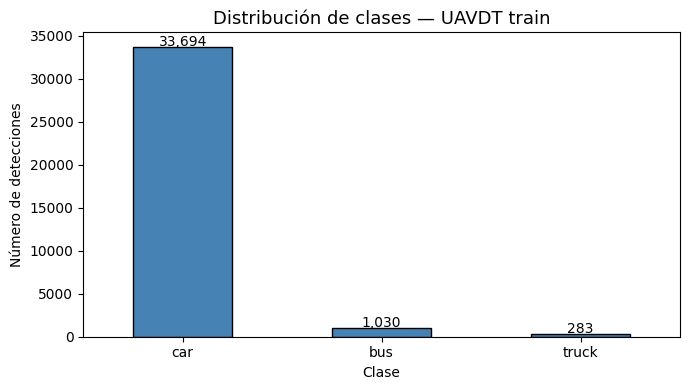

In [4]:
# ── Distribución de clases ────────────────────────────────────────────────────
class_counts=df_u["class"].value_counts()
class_pct=(class_counts / len(df_u) * 100).round(2)

class_summary=pd.DataFrame({
    "detecciones":class_counts,
    "porcentaje": class_pct
})

ratio = class_counts.max()/class_counts.min()

print(f"Total detecciones:{len(df_u):,}")
print(f"Clase mayoritaria:{class_counts.idxmax()} ({class_counts.max():,})")
print(f"Clase minoritaria:{class_counts.idxmin()} ({class_counts.min():,})")
print(f"Ratio desbalance :{ratio:.1f}x")
print()
print(class_summary)

# Gráfica
fig, ax=plt.subplots(figsize=(7, 4))
class_counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Distribución de clases — UAVDT train", fontsize=13)
ax.set_xlabel("Clase")
ax.set_ylabel("Número de detecciones")
ax.set_xticklabels(class_counts.index, rotation=0)
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 100, f"{v:,}", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig(output_dir / "01_distribucion_clases_uavdt.png", dpi=150, bbox_inches="tight")
plt.show()
class_summary.to_csv(tables_dir / "01_distribucion_clases_uavdt.csv")

## 3. Comparativa VisDrone vs UAVDT

Comparamos los hallazgos clave de ambos datasets para cuantificar
el **domain shift** que el modelo entrenado en VisDrone enfrentará
al evaluarse en UAVDT.

Las clases `car`, `truck` y `bus` son comunes a ambos datasets,
lo que permite evaluación cruzada directa sin reentrenamiento.

In [5]:
# Comparativa VisDrone vs UAVDT 

comparativa=pd.DataFrame({
    "Métrica":[
        "Imágenes (train)",
        "Detecciones (train)",
        "Número de clases",
        "Ratio de desbalance",
        "Densidad media (obj/img)",
    ],
    "VisDrone":[
        "6,470",
        "343,171",
        "10",
        "44.7x",
        "53.0",
    ],
    "UAVDT":[
        f"{df_u['image'].nunique():,}",
        f"{len(df_u):,}",
        "3",
        f"{ratio:.1f}x",
        f"{len(df_u) / df_u['image'].nunique():.1f}",
    ]
})

print(comparativa.to_string(index=False))
comparativa.to_csv(tables_dir / "03_comparativa_visdrone_uavdt.csv", index=False)


                 Métrica VisDrone  UAVDT
        Imágenes (train)    6,470  1,266
     Detecciones (train)  343,171 35,007
        Número de clases       10      3
     Ratio de desbalance    44.7x 119.1x
Densidad media (obj/img)     53.0   27.7
